# T10: Data Visualization and Linear Regression
CHE-226, Programming and Data Science

**Learning objective:** plot process data and time series with Matplotlib and pandas, fit a straight line to data with linregress and scikit-learn, and judge the fit with residuals and R squared before trusting its predictions.

**Teaches:** (KA-01)

*Spans two class meetings; see the class break marker partway through.*

## Agenda: This Class
1. Plotting with Matplotlib
2. Several series on one plot
3. Time series and rolling averages
4. What is a linear relationship?
5. Fitting a line with linregress

# 1. Plotting with Matplotlib

### Concept
`plt.subplots` makes a figure and axes; `ax.plot(x, y)` draws a line. Always label both axes with units and give the plot a title.

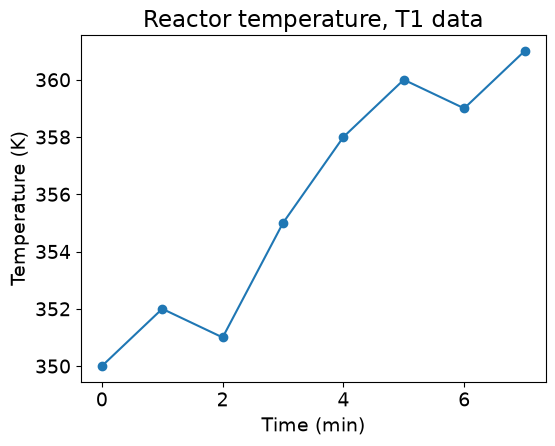

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 14})

t_min = np.arange(8)                                  # minutes
T_K = np.array([350, 352, 351, 355, 358, 360, 359, 361])
fig, ax = plt.subplots(figsize=(6, 4.5))              # 4:3 figure
ax.plot(t_min, T_K, marker="o")
ax.set_xlabel("Time (min)"); ax.set_ylabel("Temperature (K)")
ax.set_title("Reactor temperature, T1 data")
plt.show()

Detailed notes: Matplotlib is the base plotting library; pandas and seaborn plots are built on it. The object-oriented style, fig, ax = plt.subplots(), gives a handle on each axes and scales to multi-panel figures, so it is worth using from the start rather than the plt.plot shortcut. marker='o' shows the actual measurements, which matters when points are sparse: the line between them is only a guide to the eye. Labels with units are not decoration; a plot without them cannot be checked or reused. This figure is pre-run so it is on screen when the section starts.

### Activity: cold call
The y-axis above starts at 350 K, not 0 K. Does that exaggerate the warming trend? When is a non-zero axis the right choice?

Answer: it magnifies an 11 K rise to fill the plot, which is appropriate when the question is about the change (is the reactor drifting?) and misleading when the question is about magnitude (how hot is it relative to zero?). A strong answer names the question the plot is meant to answer; ax.set_ylim(0, 400) would flatten the trend.

# 2. Several Series on One Plot

### Concept
Calling `ax.plot` again adds another series to the same axes. `label=` plus `ax.legend()` identifies each one; line styles keep them distinguishable in print.

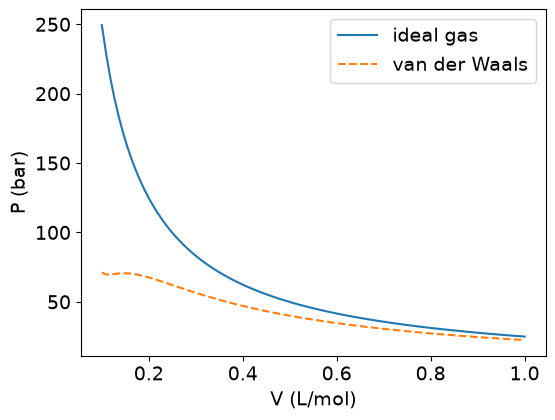

In [ ]:
R, T = 0.08314, 300.0                 # L bar/(mol K), K
a_w, b_w = 3.640, 0.04267             # van der Waals a, b for CO2
V = np.linspace(0.1, 1.0, 100)        # molar volume, L/mol
P_ideal = R * T / V
P_vdw = R * T / (V - b_w) - a_w / V**2  # real-gas correction

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(V, P_ideal, label="ideal gas")
ax.plot(V, P_vdw, "--", label="van der Waals")
ax.set_xlabel("V (L/mol)"); ax.set_ylabel("P (bar)"); ax.legend()
plt.show()

Detailed notes: Every ax.plot call on the same axes adds a series; label plus ax.legend() builds the key. A format string such as '--' or 'o-' sets line style and markers quickly; using style as well as color keeps the plot readable for color-blind viewers and on a grayscale printout. Because V is a NumPy array (T7), each pressure curve is one vectorized line, no loop needed. The van der Waals equation corrects the ideal gas law for the volume the molecules themselves occupy (b) and the attraction between them (a); at large volumes both corrections fade and the curves meet. The constants are standard textbook values for CO2.

**Sneak Peek: T-04.02.01 PVT Behaviour (KA-04)**
Real gases depart from PV = nRT at high pressure and small volume. Plotting both curves shows where, and by how much. You will study equations of state fully in chemical engineering thermodynamics.

### Activity: predict then run
At V = 0.5 L/mol, is the real-gas pressure of CO2 above or below the ideal-gas value? Decide from the plot, then check the numbers.

In [ ]:
V1 = 0.5
print(f"ideal {R * T / V1:.1f} bar, "
      f"vdW {R * T / (V1 - b_w) - a_w / V1**2:.1f} bar")

Answer: below: about 49.9 bar ideal versus 40.0 bar van der Waals. At this volume the attraction term a/V^2 outweighs the excluded-volume term, so molecules pull on each other and hit the walls less hard. At very small V the b term would eventually win.

# 3. Time Series and Rolling Averages

### Concept
A time series is a sequence of values in time order. A pandas Series with a time index plots in one call, and `rolling(n).mean()` smooths noise with a moving average.

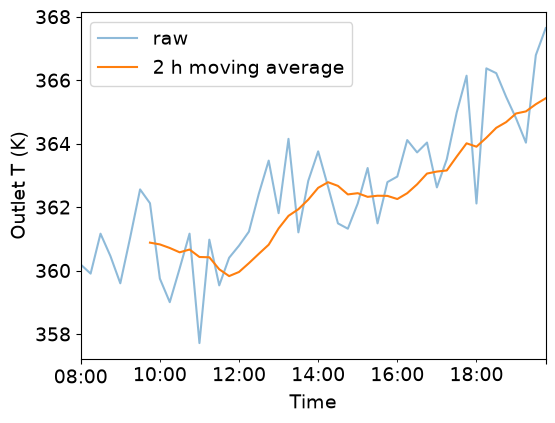

In [ ]:
import pandas as pd
rng = np.random.default_rng(0)                       # seeded noise
times = pd.date_range("2026-10-05 08:00", periods=48, freq="15min")
T_out = pd.Series(360 + 0.1 * np.arange(48)          # slow drift
                  + rng.normal(0, 1.5, 48), index=times)

ax = T_out.plot(figsize=(6, 4.5), alpha=0.5, label="raw")
T_out.rolling(8).mean().plot(ax=ax, label="2 h moving average")
ax.set_xlabel("Time"); ax.set_ylabel("Outlet T (K)"); ax.legend()
plt.show()

Detailed notes: A univariate time series tracks one quantity (outlet temperature); a multivariate one tracks several (temperature, pressure, and flow from the same unit). Common tasks are smoothing, spotting trends and seasonality, detecting anomalies, and forecasting. pd.date_range builds a regular time index, and Series.plot calls Matplotlib and uses the index as the x-axis. rolling(8).mean() averages each value with the seven before it, two hours at 15-minute sampling: wider windows smooth more but respond later to real changes. The data are synthetic, a slow upward drift plus random noise, generated with a fixed seed as in T4.

### Activity: predict then run
A 3-point rolling mean of five readings. How many values come back, and what are the first two?

In [ ]:
s = pd.Series([350.0, 353.0, 356.0, 353.0, 350.0])
print(s.rolling(3).mean().tolist())

Answer: five values: [nan, nan, 353.0, 354.0, 353.0]. A window of 3 needs three readings, so the first two positions have no average and are NaN (not a number, pandas' marker for missing data). The length is preserved so the result lines up with the original index.

# 4. What Is a Linear Relationship?

### Concept
Two quantities are linearly related if `y = m x + b`: the slope `m` is the change in y per unit x, and the intercept `b` is y at x = 0. Each has units.

In [ ]:
m = 0.0410          # slope: thermocouple output, mV per C
b = 0.00            # intercept: output at 0 C, mV

T_C = np.array([0.0, 100.0, 250.0])
mV = m * T_C + b    # a line, vectorized
print(mV)

Detailed notes: Many engineering relationships are linear, or close to linear over a limited range: a thermocouple's voltage versus temperature, pressure drop versus flow in laminar flow, a calibration curve for an analyzer. The slope's units are y-units per x-unit (here mV per degree), and it often has a physical meaning, such as sensitivity. The intercept is the value at x = 0, which may be outside the measured range and so not physically meaningful. Simple linear regression, next, estimates m and b from noisy data rather than assuming them. A type K thermocouple produces roughly 0.041 mV per degree C near room temperature, the value used here.

### Activity: cold call
A calibration line for a flow meter reads `flow = 2.5 * signal - 10`, with flow in kg/h and signal in mA. What are the units of 2.5 and of -10, and what does -10 tell you?

Answer: 2.5 is kg/h per mA and -10 is kg/h. The negative intercept is the flow the line predicts at zero signal, which is impossible; it means the line is only valid inside the calibrated range (for a 4 to 20 mA signal it starts at 0 kg/h at 4 mA).

# 5. Fitting a Line with linregress

### Concept
`scipy.stats.linregress(x, y)` finds the least-squares line through noisy data. It returns the slope, the intercept, and `rvalue`, the correlation coefficient.

In [ ]:
from scipy import stats

rng = np.random.default_rng(1)
T_cal = np.arange(0, 301, 50.0)                   # bath temps, C
mV_cal = 0.041 * T_cal + rng.normal(0, 0.15, 7)   # noisy readings

fit = stats.linregress(T_cal, mV_cal)
print(f"slope = {fit.slope:.4f} mV/C")
print(f"intercept = {fit.intercept:.3f} mV, r = {fit.rvalue:.4f}")

Detailed notes: Least squares chooses the slope and intercept that minimize the sum of squared vertical distances between the data and the line. The fitted slope is close to, but not exactly, the true 0.041, because of the noise; more calibration points would tighten it. rvalue, the Pearson correlation coefficient, runs from -1 to 1: its sign follows the slope, and values near plus or minus 1 mean the points lie close to a line. linregress also returns a p-value and the standard error of the slope, which statistics courses use to judge whether the slope is real. The calibration data are synthetic, generated from the known line plus random noise.

### Activity: predict then run
Using the fitted slope and intercept printed above, estimate the reading at 180 C by hand, then check.

In [ ]:
print(f"{fit.slope * 180 + fit.intercept:.2f} mV")

Answer: about 7.4 mV (0.041 x 180 = 7.38, plus a small intercept). The exact value depends on the fitted numbers; the point is that prediction is just the line equation evaluated at a new x.

## Class Break
Covered so far: Matplotlib plots, several series, time series and rolling means, linear relationships, fitting with linregress.

## Agenda: Next Class
6. Plotting the data with the fitted line
7. Predictions: interpolation and extrapolation
8. Residuals and R squared
9. Regression on material property data
10. Putting it together: the same fit in scikit-learn

# 6. Plotting the Data with the Fitted Line

### Concept
Show measured points as markers and the fitted line as a line, on the same axes. The eye can then judge the fit at once.

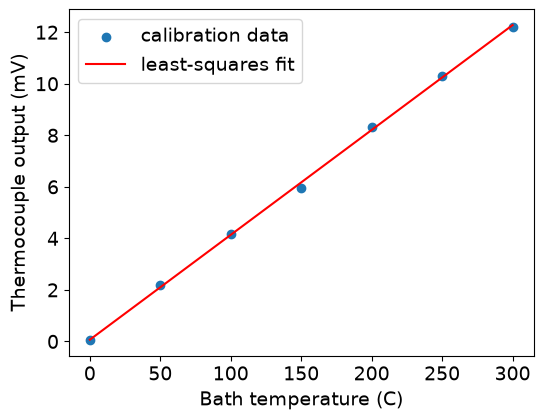

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(T_cal, mV_cal, label="calibration data")
T_line = np.linspace(0, 300, 2)                    # two points
ax.plot(T_line, fit.slope * T_line + fit.intercept,
        "r-", label="least-squares fit")
ax.set_xlabel("Bath temperature (C)")
ax.set_ylabel("Thermocouple output (mV)")
ax.legend()
plt.show()

Detailed notes: Markers for data and a line for the model is the convention: it separates what was measured from what was fitted. A straight line only needs two points to draw, which is why T_line has just two values; a curved model would need a dense linspace. Always plot the data with the fit before trusting any statistic: data with very different shapes can share the same r value (Anscombe's quartet is the classic example), and only a plot reveals curvature, outliers, or clusters. seaborn's regplot does data, fit, and a confidence band in one call, built on these same Matplotlib pieces.

### Activity: cold call
The fitted line does not pass through every point. Is the fit wrong? What is least squares actually doing?

Answer: no: the scatter is measurement noise, and no straight line can pass through every noisy point. Least squares picks the one line that makes the sum of squared vertical distances as small as possible, balancing points above and below. A line through every point would be fitting the noise.

# 7. Predictions: Interpolation and Extrapolation

### Concept
Predicting inside the range of the data is interpolation and is usually safe. Predicting outside it is extrapolation: the line keeps going, but the physics may not.

In [ ]:
def mV_to_C(mV):
    """Invert the calibration: temperature from a reading."""
    return (mV - fit.intercept) / fit.slope

print(f"{mV_to_C(6.0):.0f} C")      # inside 0-300 C: interpolation
print(f"{mV_to_C(45.0):.0f} C")     # far outside: extrapolation

Detailed notes: Inverting the fitted line turns a calibration into a measurement: read the voltage, compute the temperature. Inside the calibrated range, the line is supported by data on both sides. Outside it, the model has no evidence: real thermocouple output is slightly nonlinear, and at high temperature the error grows; many processes change behavior entirely (a phase change, a reaction starting). Regression software will happily return a number for any x, so the responsibility for checking the range is the engineer's. Reporting the calibrated range next to any fitted equation is good practice.

### Activity: cold call
The function returned about 1100 C for 45 mV. Would you put that number in a report? What would you do first?

Answer: no, not without checking: 45 mV is far beyond the 0 to 300 C calibration, so the answer rests on assuming the line stays straight. Calibrate at higher temperatures, or use the standard reference table for the thermocouple type, before trusting it.

# 8. Residuals and R Squared

### Concept
A residual is measured minus predicted. R squared, `r**2`, is the fraction of the variation in y that the line explains: 1 is a perfect fit, 0 explains nothing.

In [ ]:
pred = fit.slope * T_cal + fit.intercept
resid = mV_cal - pred                       # measured - predicted
print(resid.round(3))
print(f"R^2 = {fit.rvalue**2:.4f}")
print(f"sum of residuals = {resid.sum():.1e}")

Detailed notes: Residuals are what the model fails to explain. For a good linear model they look like random noise: no trend, no curve, no funnel shape when plotted against x; a curved residual pattern means a straight line is the wrong model even if R squared is high. For a least-squares fit with an intercept, the residuals always sum to (numerically) zero. R squared equals r squared for simple linear regression; 0.99 is typical for a calibration and far higher than most process data will give. A high R squared does not prove causation or that the model extrapolates.

### Activity: predict then run
These points lie exactly on y = 2x + 1. What slope, intercept, and R squared will linregress report?

In [ ]:
x = np.array([0.0, 1.0, 2.0, 3.0])
f = stats.linregress(x, 2 * x + 1)
print(f.slope, f.intercept, f.rvalue ** 2)

Answer: 2.0 1.0 1.0 (possibly with floating-point noise in the last digit). With no scatter, the line explains all of the variation, so R squared is 1.

# 9. Regression on Material Property Data

### Concept
The same fit works on any pair of measured quantities. Here: how the tensile strength of plain carbon steel changes with its carbon content.

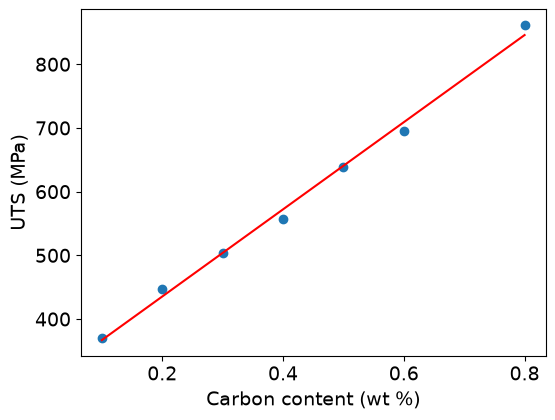

In [ ]:
rng = np.random.default_rng(7)
C_pct = np.array([0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.80])
UTS = 300 + 700 * C_pct + rng.normal(0, 25, 7)   # MPa, synthetic

fit_s = stats.linregress(C_pct, UTS)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(C_pct, UTS)
ax.plot(C_pct, fit_s.slope * C_pct + fit_s.intercept, "r-")
ax.set_xlabel("Carbon content (wt %)"); ax.set_ylabel("UTS (MPa)")
plt.show()

Detailed notes: Nothing in the code is specific to thermocouples: linregress, the plot, and the residual checks apply unchanged to any x and y. Ultimate tensile strength (UTS) of plain carbon steel rises with carbon content over roughly this range, because carbon forms hard iron carbide; ductility falls at the same time. The numbers here are synthetic, generated around a straight line to show the method, and real steel data depend strongly on heat treatment. Material selection for process equipment trades strength against ductility, weldability, and corrosion resistance.

**Sneak Peek: T-12.01.02 Mechanical Properties (KA-12)**
Strength, hardness, and ductility depend on composition and processing. A regression line gives a first estimate from data. You will study material properties and selection fully in materials engineering.

### Activity: predict then run
Read the slope from the plot. Roughly what strength does the model predict for 0.45 wt% carbon?

In [ ]:
print(f"slope {fit_s.slope:.0f} MPa per wt%, R^2 {fit_s.rvalue**2:.3f}")
print(f"UTS(0.45%) = {fit_s.slope * 0.45 + fit_s.intercept:.0f} MPa")

Answer: roughly 600 to 650 MPa (the generating line gives 300 + 700 x 0.45 = 615 MPa; the fitted value differs slightly because of the noise). 0.45 is inside the data range, so this is interpolation.

# 10. Putting It Together: The Same Fit in scikit-learn

### Concept
scikit-learn's `LinearRegression` does the same least-squares fit with the fit/predict/score pattern used by every model in T15. Its X must be 2D: rows are samples, columns are features.

In [ ]:
from sklearn.linear_model import LinearRegression

X = T_cal.reshape(-1, 1)            # 7 samples x 1 feature
model = LinearRegression()
model.fit(X, mV_cal)                # learn slope and intercept
print(model.coef_, model.intercept_)
print(model.predict([[180.0]]))     # same prediction as before
print(f"R^2 = {model.score(X, mV_cal):.4f}")

Detailed notes: The numbers match linregress exactly, since both solve the same least-squares problem; what changes is the interface. Every scikit-learn model is created, then fit on data, then used to predict, and score reports a default quality measure (R squared for regressors). X is 2D because models generally take many input features per sample (temperature, pressure, flow), so even one feature needs an explicit column: reshape(-1, 1) from T7. coef_ holds one slope per feature. T15 swaps LinearRegression for classifiers and adds training and test sets.

### Activity: cold call
What would go wrong with `model.fit(T_cal, mV_cal)`, and why does scikit-learn insist on a 2D X?

In [ ]:
LinearRegression().fit(T_cal, mV_cal)

Answer: it raises ValueError asking for a 2D array. scikit-learn cannot tell whether a 1D array is 7 samples of one feature or one sample of 7 features, so it requires the shape to be explicit. reshape(-1, 1) says 7 samples, 1 feature.

## Recap and Lab Practice
- Label every axis with units; one axes can hold several series with a legend; pandas plots and rolling means make time series quick.
- Least squares fits y = m x + b; slope and intercept have units and meaning. linregress and scikit-learn give the same line.
- Check residuals and R squared, and be wary of extrapolation outside the data.

Lab practice: calibrate a sensor from noisy data, plot data plus fit plus residuals, and compare ideal and van der Waals curves for another gas; ask if you want them turned into a lab worksheet.

Next lecture: T15, machine learning.